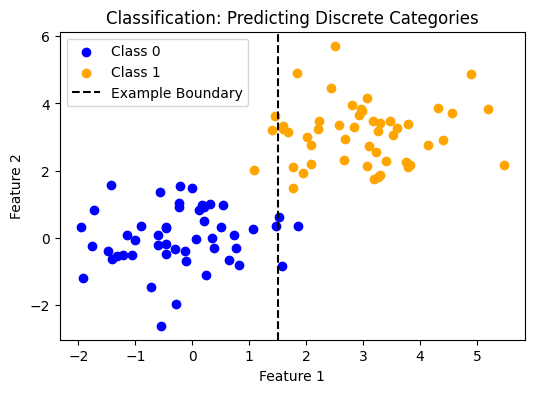

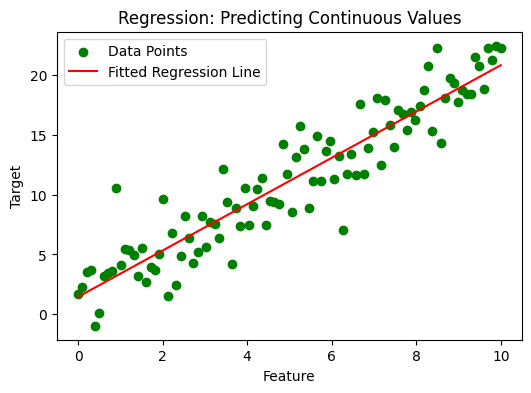

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Classification Example: Predicting discrete categories (e.g., Class 0 or Class 1)
# Here, data points are grouped into two distinct classes based on features.
class0_x = np.random.normal(0, 1, 50)
class0_y = np.random.normal(0, 1, 50)
class1_x = np.random.normal(3, 1, 50)
class1_y = np.random.normal(3, 1, 50)

plt.figure(figsize=(6, 4))
plt.scatter(class0_x, class0_y, color='blue', label='Class 0')
plt.scatter(class1_x, class1_y, color='orange', label='Class 1')
plt.title('Classification: Predicting Discrete Categories')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
# To depict a simple decision boundary (optional, for clarity)
plt.axvline(x=1.5, color='black', linestyle='--', label='Example Boundary')
plt.legend()
plt.show()

# Regression Example: Predicting continuous values
# Here, we have a feature and a target with a linear relationship plus noise.
# The goal is to fit a line that predicts the target value for any feature.
x = np.linspace(0, 10, 100)
y = 2 * x + 1 + np.random.normal(0, 2, 100)

# Fit a linear regression line using numpy
coefficients = np.polyfit(x, y, 1)
p = np.poly1d(coefficients)

plt.figure(figsize=(6, 4))
plt.scatter(x, y, color='green', label='Data Points')
plt.plot(x, p(x), color='red', label='Fitted Regression Line')
plt.title('Regression: Predicting Continuous Values')
plt.xlabel('Feature')
plt.ylabel('Target')
plt.legend()
plt.show()

/var/folders/n8/vnvrbrx950b17b93f4xx47k80000gn/T/ipykernel_50563/1798304797.py:15: RuntimeWarning: invalid value encountered in divide
  p_new = np.maximum(p / np.sum(p), epsilon)


Iteration 100: Cost = 2.808654757961401
Iteration 200: Cost = 2.8015130837979596
Iteration 300: Cost = 0.6438417181701255
Iteration 400: Cost = 0.6380974866846527


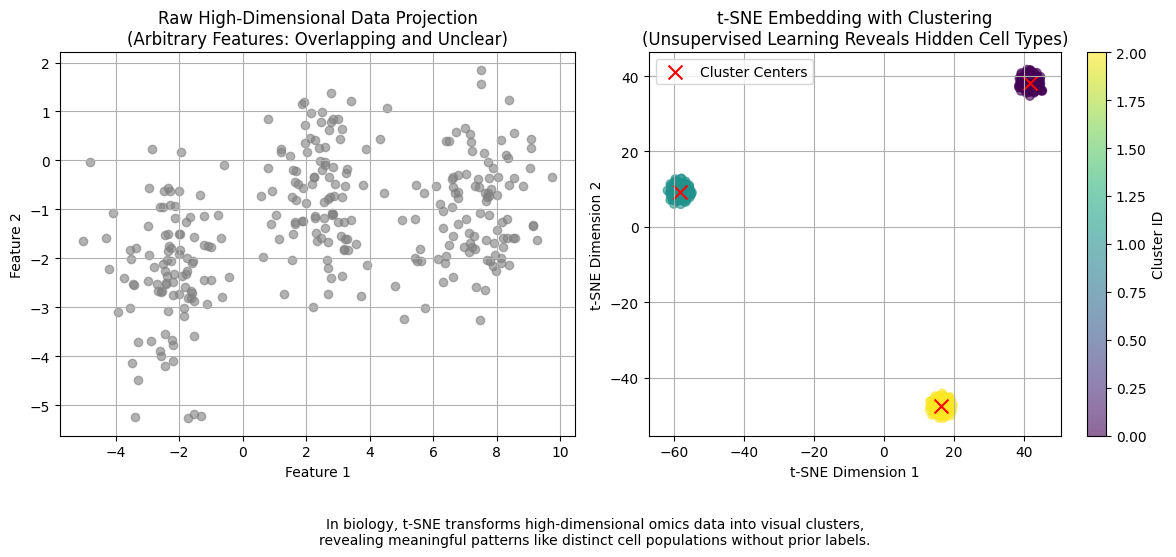

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.vq import kmeans, vq

# t-SNE implementation functions (adapted from the NumPy-only code)

def grid_search(diff_i: np.ndarray, i: int, perplexity: int) -> float:
    result = np.inf
    norm = np.linalg.norm(diff_i, axis=1)
    std_norm = np.std(norm)
    for sigma_search in np.linspace(0.01 * std_norm, 5 * std_norm, 200):
        p = np.exp(-(norm**2) / (2 * sigma_search**2))
        p[i] = 0
        epsilon = np.nextafter(0, 1)
        p_new = np.maximum(p / np.sum(p), epsilon)
        H = -np.sum(p_new * np.log2(p_new))
        if np.abs(np.log(perplexity) - H * np.log(2)) < np.abs(result):
            result = np.log(perplexity) - H * np.log(2)
            sigma = sigma_search
    return sigma

def get_original_pairwise_affinities(X: np.ndarray, perplexity: int = 30) -> np.ndarray:
    n = len(X)
    p_ij = np.zeros(shape=(n, n))
    for i in range(0, n):
        diff = X[i] - X
        sigma_i = grid_search(diff, i, perplexity)
        norm = np.linalg.norm(diff, axis=1)
        p_ij[i, :] = np.exp(-(norm**2) / (2 * sigma_i**2))
        p_ij[i, i] = 0
        p_ij[i, :] = p_ij[i, :] / np.sum(p_ij[i, :])
    epsilon = np.nextafter(0, 1)
    p_ij = np.maximum(p_ij, epsilon)
    return p_ij

def get_symmetric_p_ij(p_ij: np.ndarray) -> np.ndarray:
    n = len(p_ij)
    p_ij_symmetric = np.zeros(shape=(n, n))
    for i in range(0, n):
        for j in range(0, n):
            p_ij_symmetric[i, j] = (p_ij[i, j] + p_ij[j, i]) / (2 * n)
    epsilon = np.nextafter(0, 1)
    p_ij_symmetric = np.maximum(p_ij_symmetric, epsilon)
    return p_ij_symmetric

def initialization(X: np.ndarray, n_dimensions: int = 2, init_method: str = 'PCA') -> np.ndarray:
    if init_method == 'random':
        return np.random.normal(loc=0, scale=1e-4, size=(len(X), n_dimensions))
    elif init_method == 'PCA':
        X_centered = X - np.mean(X, axis=0)
        U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
        return U[:, :n_dimensions] * S[:n_dimensions]
    else:
        raise ValueError("Initialization must be 'random' or 'PCA'")

def get_low_dimensional_affinities(Y: np.ndarray) -> np.ndarray:
    n = len(Y)
    q_ij = np.zeros(shape=(n, n))
    for i in range(0, n):
        diff = Y[i] - Y
        norm = np.linalg.norm(diff, axis=1)
        q_ij[i, :] = (1 + norm**2) ** (-1)
    q_ij[np.diag_indices(n)] = 0
    q_ij = q_ij / q_ij.sum()
    epsilon = np.nextafter(0, 1)
    q_ij = np.maximum(q_ij, epsilon)
    return q_ij

def get_gradient(p_ij: np.ndarray, q_ij: np.ndarray, Y: np.ndarray) -> np.ndarray:
    n = len(p_ij)
    gradient = np.zeros(shape=(n, Y.shape[1]))
    for i in range(0, n):
        diff = Y[i] - Y
        A = np.array([(p_ij[i, :] - q_ij[i, :])])
        B = np.array([(1 + np.linalg.norm(diff, axis=1)) ** (-1)])
        C = diff
        gradient[i] = 4 * np.sum((A * B).T * C, axis=0)
    return gradient

def tsne(X: np.ndarray, perplexity: int = 30, T: int = 500, eta: int = 200, early_exaggeration: int = 12, n_dimensions: int = 2) -> np.ndarray:
    n = len(X)
    p_ij = get_original_pairwise_affinities(X, perplexity)
    p_ij_symmetric = get_symmetric_p_ij(p_ij)
    Y = initialization(X, n_dimensions, 'PCA')
    Y_prev = np.zeros_like(Y)
    Y_curr = Y.copy()
    for t in range(1, T):
        if t < 250:
            alpha = 0.5
            exaggeration = early_exaggeration
        else:
            alpha = 0.8
            exaggeration = 1
        q_ij = get_low_dimensional_affinities(Y_curr)
        gradient = get_gradient(exaggeration * p_ij_symmetric, q_ij, Y_curr)
        Y_next = Y_curr - eta * gradient + alpha * (Y_curr - Y_prev)
        Y_prev = Y_curr.copy()
        Y_curr = Y_next.copy()
        if t % 100 == 0:
            cost = np.sum(p_ij_symmetric * np.log(p_ij_symmetric / q_ij))
            print(f"Iteration {t}: Cost = {cost}")
    return Y_curr

# Generate synthetic high-dimensional data: 3 clusters in 10 dimensions, representing different 'cell types' in gene expression data
np.random.seed(42)
dim = 10
n_points = 100
mean1 = np.random.normal(0, 5, dim)
mean2 = np.random.normal(0, 5, dim)
mean3 = np.random.normal(0, 5, dim)
cluster1 = np.random.normal(0, 1, (n_points, dim)) + mean1
cluster2 = np.random.normal(0, 1, (n_points, dim)) + mean2
cluster3 = np.random.normal(0, 1, (n_points, dim)) + mean3
data = np.vstack([cluster1, cluster2, cluster3])
np.random.shuffle(data)

# Plot raw data projection on two arbitrary features - looks overlapping and unstructured
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(data[:, 0], data[:, 1], color='gray', alpha=0.6)
plt.title('Raw High-Dimensional Data Projection\n(Arbitrary Features: Overlapping and Unclear)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)

# Apply t-SNE to reduce to 2D
embedded = tsne(data, perplexity=30, T=500, eta=200, early_exaggeration=12, n_dimensions=2)

# Perform K-Means on the t-SNE embedding to discover clusters
centroids, _ = kmeans(embedded, 3)
labels, _ = vq(embedded, centroids)

# Plot the t-SNE result with discovered clusters
plt.subplot(1, 2, 2)
scatter = plt.scatter(embedded[:, 0], embedded[:, 1], c=labels, cmap='viridis', alpha=0.6)
plt.scatter(centroids[:, 0], centroids[:, 1], marker='x', color='red', s=100, label='Cluster Centers')
plt.title('t-SNE Embedding with Clustering\n(Unsupervised Learning Reveals Hidden Cell Types)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.colorbar(scatter, label='Cluster ID')
plt.legend()
plt.grid(True)

# Add inspiring text
plt.figtext(0.5, -.1, 'In biology, t-SNE transforms high-dimensional omics data into visual clusters,\nrevealing meaningful patterns like distinct cell populations without prior labels.', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

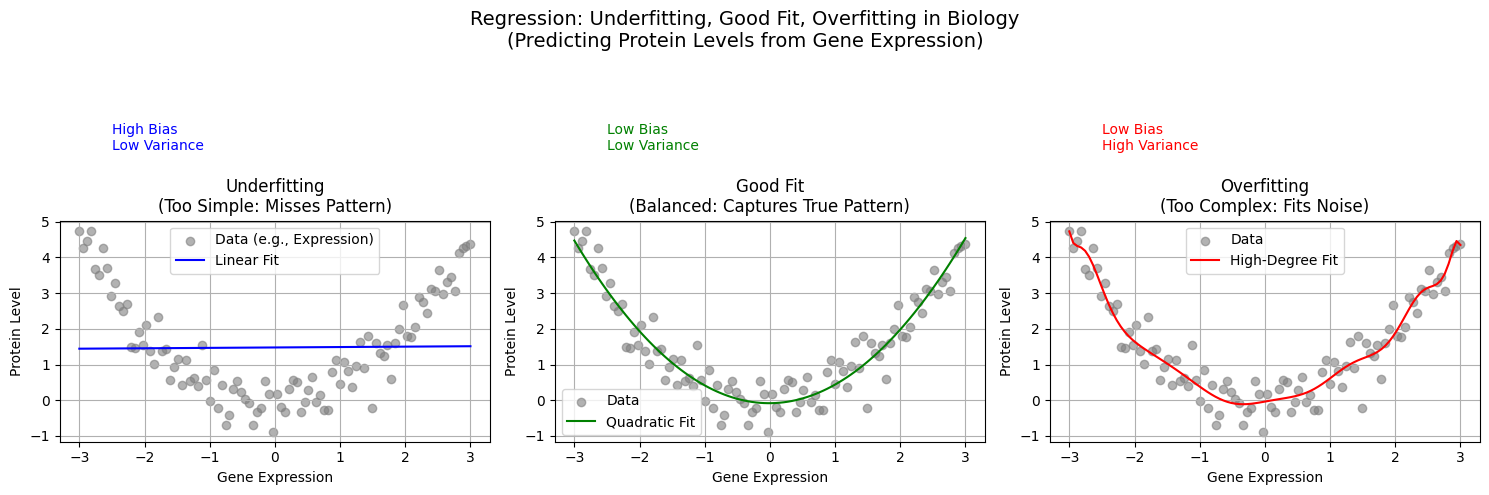

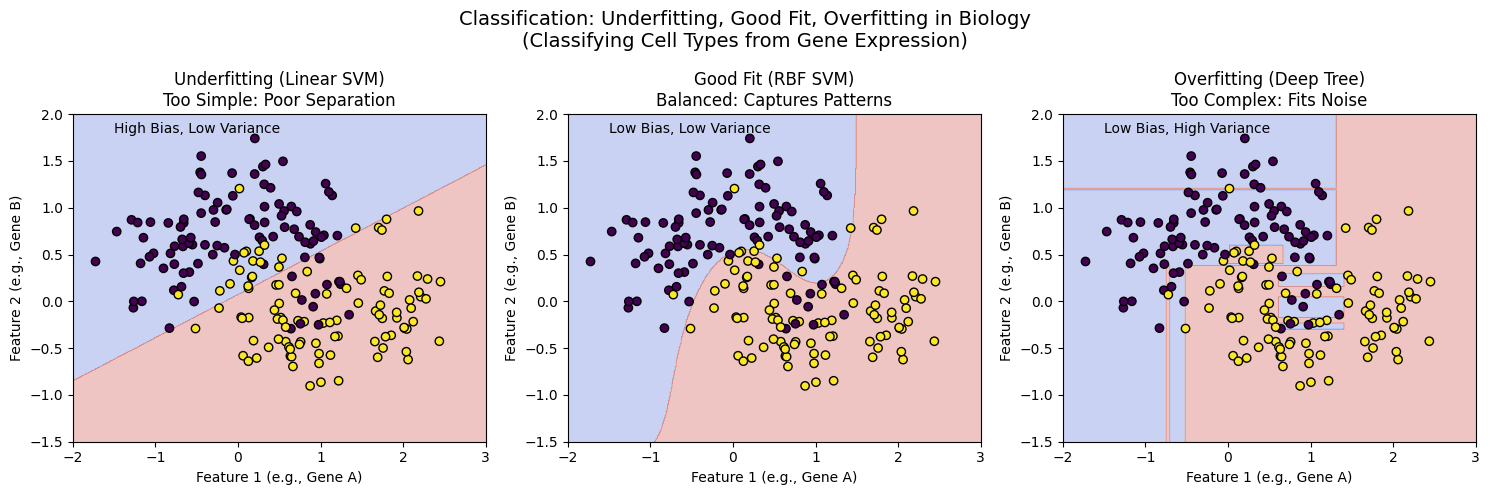

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.datasets import make_moons
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# Set random seed for reproducibility
np.random.seed(42)

# --- Regression: Underfitting, Good Fit, Overfitting ---

# Generate synthetic quadratic data with noise
X = np.linspace(-3, 3, 100).reshape(-1, 1)  # Shape (100, 1)
y = 0.5 * X.flatten()**2 + np.random.normal(0, 0.5, 100)  # Shape (100,)
X_flat = X.flatten()  # Shape (100,) for plotting
y_flat = y  # Already (100,) for plotting

# Underfitting: Linear model (too simple)
model_under = LinearRegression()
model_under.fit(X, y.reshape(-1, 1))
y_under = model_under.predict(X)

# Good fit: Quadratic polynomial (matches true data structure)
model_good = make_pipeline(PolynomialFeatures(2), LinearRegression())
model_good.fit(X, y.reshape(-1, 1))
y_good = model_good.predict(X)

# Overfitting: High-degree polynomial (degree 15, fits noise)
model_over = make_pipeline(PolynomialFeatures(15), LinearRegression())
model_over.fit(X, y.reshape(-1, 1))
y_over = model_over.predict(X)

# Plot regression figures
plt.figure(figsize=(15, 5))
plt.suptitle('Regression: Underfitting, Good Fit, Overfitting in Biology\n(Predicting Protein Levels from Gene Expression)', fontsize=14)

plt.subplot(1, 3, 1)
plt.scatter(X_flat, y_flat, color='gray', alpha=0.6, label='Data (e.g., Expression)')
plt.plot(X_flat, y_under.flatten(), color='blue', label='Linear Fit')
plt.title('Underfitting\n(Too Simple: Misses Pattern)')
plt.xlabel('Gene Expression')
plt.ylabel('Protein Level')
plt.legend()
plt.grid(True)
plt.text(-2.5, 7, 'High Bias\nLow Variance', fontsize=10, color='blue')

plt.subplot(1, 3, 2)
plt.scatter(X_flat, y_flat, color='gray', alpha=0.6, label='Data')
plt.plot(X_flat, y_good.flatten(), color='green', label='Quadratic Fit')
plt.title('Good Fit\n(Balanced: Captures True Pattern)')
plt.xlabel('Gene Expression')
plt.ylabel('Protein Level')
plt.legend()
plt.grid(True)
plt.text(-2.5, 7, 'Low Bias\nLow Variance', fontsize=10, color='green')

plt.subplot(1, 3, 3)
plt.scatter(X_flat, y_flat, color='gray', alpha=0.6, label='Data')
plt.plot(X_flat, y_over.flatten(), color='red', label='High-Degree Fit')
plt.title('Overfitting\n(Too Complex: Fits Noise)')
plt.xlabel('Gene Expression')
plt.ylabel('Protein Level')
plt.legend()
plt.grid(True)
plt.text(-2.5, 7, 'Low Bias\nHigh Variance', fontsize=10, color='red')

plt.tight_layout()
plt.show()

# --- Classification: Underfitting, Good Fit, Overfitting ---

# Generate moons dataset with noise (e.g., classifying cell types)
X_class, y_class = make_moons(n_samples=200, noise=0.3, random_state=42)

# Underfitting: Linear SVM (too simple for nonlinear data)
model_under_class = SVC(kernel='linear')
model_under_class.fit(X_class, y_class)

# Good fit: RBF SVM (captures nonlinear patterns)
model_good_class = SVC(kernel='rbf', gamma=1)
model_good_class.fit(X_class, y_class)

# Overfitting: Decision Tree with no depth limit (memorizes noise)
model_over_class = DecisionTreeClassifier(max_depth=None, random_state=42)
model_over_class.fit(X_class, y_class)

# Function to plot decision boundaries
def plot_decision_boundary(model, ax, title, text):
    xx, yy = np.meshgrid(np.linspace(-2, 3, 500), np.linspace(-1.5, 2, 500))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap='coolwarm', alpha=0.3)
    ax.scatter(X_class[:, 0], X_class[:, 1], c=y_class, cmap='viridis', edgecolor='k')
    ax.set_title(title)
    ax.set_xlabel('Feature 1 (e.g., Gene A)')
    ax.set_ylabel('Feature 2 (e.g., Gene B)')
    ax.text(-1.5, 1.8, text, fontsize=10, color='black')

# Plot classification figures
plt.figure(figsize=(15, 5))
plt.suptitle('Classification: Underfitting, Good Fit, Overfitting in Biology\n(Classifying Cell Types from Gene Expression)', fontsize=14)

ax1 = plt.subplot(1, 3, 1)
plot_decision_boundary(model_under_class, ax1, 'Underfitting (Linear SVM)\nToo Simple: Poor Separation', 'High Bias, Low Variance')

ax2 = plt.subplot(1, 3, 2)
plot_decision_boundary(model_good_class, ax2, 'Good Fit (RBF SVM)\nBalanced: Captures Patterns', 'Low Bias, Low Variance')

ax3 = plt.subplot(1, 3, 3)
plot_decision_boundary(model_over_class, ax3, 'Overfitting (Deep Tree)\nToo Complex: Fits Noise', 'Low Bias, High Variance')

plt.tight_layout()
plt.show()